<a href="https://colab.research.google.com/github/nluizsoliveira/Solved-Problems/blob/main/Estatistica_Morettin_Bussab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Resoluções Estatística - Morettin / Bussab

## Capítulo 1
Não possui exerícios.

## Capítulo 2

## 2.1
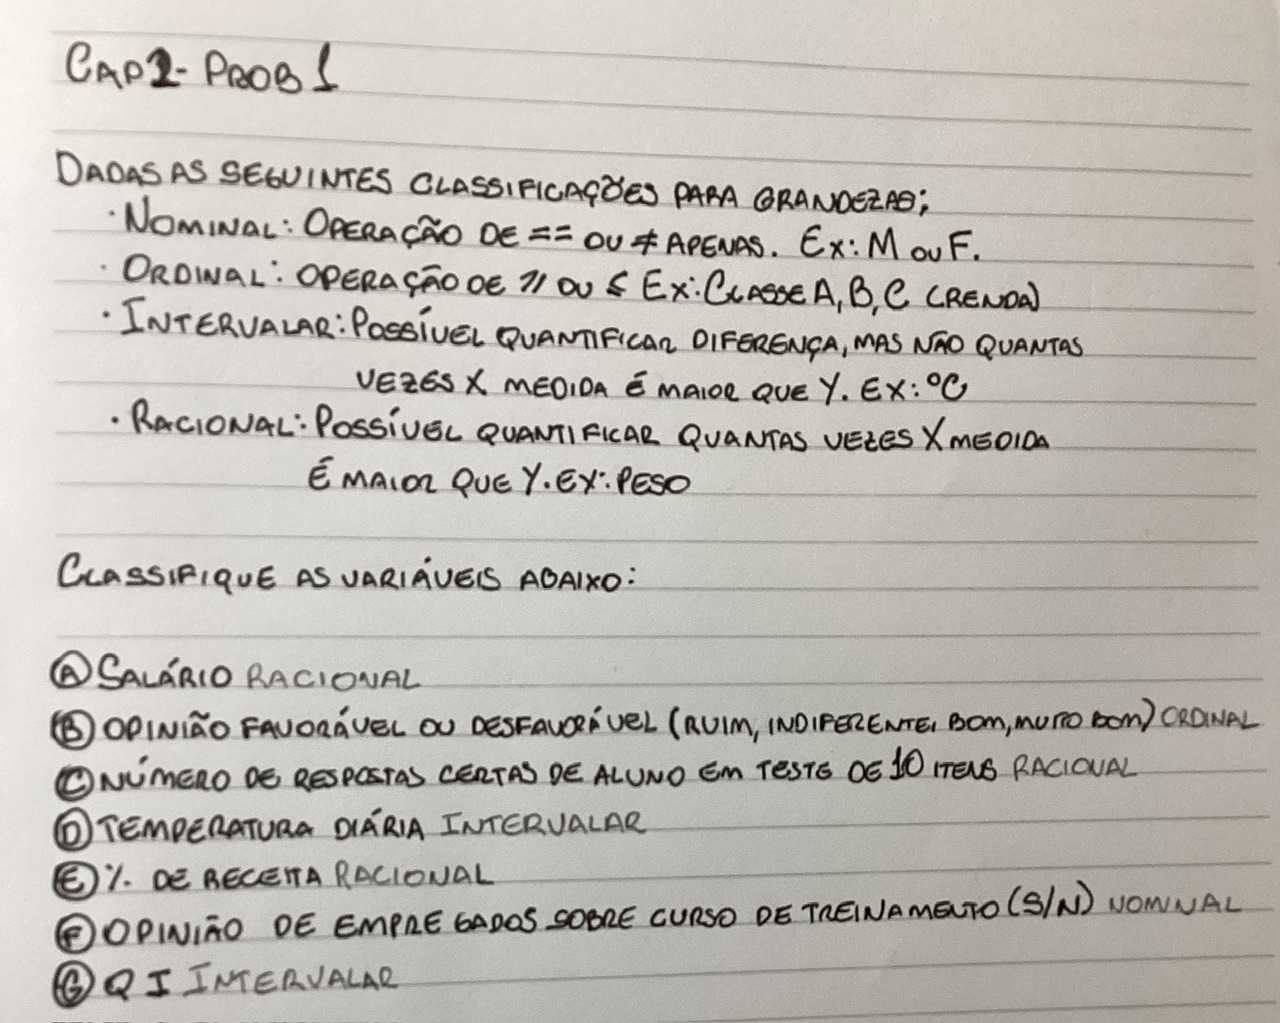

### Cap 2 Ex 2

Construa a distribuição de frequências
da tabela abaixo para as variáveis:

- a: Estado civil.
- b: Região de procedência.
- c: Número de filhos dos empregados casados.
- d: Idade.

In [44]:
import math
from io import StringIO

import numpy as np
import pandas as pd

def get_integer_bins(bin_size, df, col):
    start = math.floor(df[col].min() / bin_size) * bin_size
    end = math.ceil(df[col].max() / bin_size) * bin_size
    return np.arange(start, end + bin_size, bin_size)
# .since .value_counts() doesn't work well for floats,
# a custom one is needed.
def get_freq_table(df, column, bin_size):
    freq = (
        pd.cut(
            df[column],
            bins=get_integer_bins(bin_size, df, column),
            right=False,
        )
        .value_counts()
        .sort_index()
    )
    freq = freq[freq > 0]
    freq.index = [
        f"[{i.left:,.0f}, {i.right:,.0f})".replace(",", ".")
        for i in freq.index
    ]

    return f"Freq {column}\n{freq.to_string()}\n"


csv = StringIO("""civil,education,children,income,age_years,age_months,region
solteiro,ensino fundamental,,4.00,26,3,interior
casado,ensino fundamental,1,4.56,32,10,capital
casado,ensino fundamental,2,5.25,36,5,capital
solteiro,ensino médio,,5.73,20,10,outra
solteiro,ensino fundamental,,6.26,40,7,outra
casado,ensino fundamental,0,6.66,28,0,interior
solteiro,ensino fundamental,,6.86,41,0,interior
solteiro,ensino fundamental,,7.39,43,4,capital
casado,ensino médio,1,7.59,34,10,capital
solteiro,ensino médio,,7.44,23,6,outra
casado,ensino médio,2,8.12,33,6,interior
solteiro,ensino fundamental,,8.46,27,11,capital
solteiro,ensino médio,,8.74,37,5,outra
casado,ensino fundamental,3,8.95,44,2,outra
casado,ensino médio,0,9.13,30,5,interior
solteiro,ensino médio,,9.35,38,8,outra
casado,ensino médio,1,9.77,31,7,capital
casado,ensino fundamental,2,9.80,39,7,outra
solteiro,superior,,10.53,25,8,interior
solteiro,ensino médio,,10.76,37,4,interior
casado,ensino médio,1,11.06,30,9,outra
solteiro,ensino médio,,11.59,34,2,capital
solteiro,ensino fundamental,,12.00,41,0,outra
casado,superior,0,12.79,26,1,outra
casado,ensino médio,2,13.23,32,5,interior
casado,ensino médio,2,13.60,35,0,outra
solteiro,ensino fundamental,,13.85,46,7,outra
casado,ensino médio,0,14.69,29,8,interior
casado,ensino médio,5,14.71,40,6,interior
casado,superior,2,15.99,35,10,capital
solteiro,ensino médio,,16.22,31,5,outra
casado,superior,1,16.61,36,4,interior
casado,superior,3,17.26,43,7,capital
solteiro,ensino médio,,18.75,33,7,capital
casado,superior,2,19.40,48,11,capital
casado,superior,3,23.30,42,2,interior
""")

df = pd.read_csv(csv)

print("\n=== Estado Civil ===")
print(df["civil"].value_counts().rename("Frequência").to_string())

print("\n=== Região de procedência ===")
print(df["region"].value_counts().rename("Frequência").to_string())

print("\n=== Número de filhos dos empregados casados ===")
print(
    df[df["civil"] == "casado"]["children"]
    .value_counts()
    .rename("Frequência").to_string()
)

print("\n=== Idade ===")
print(get_freq_table(df, 'age_years', 10))


=== Estado Civil ===
civil
casado      20
solteiro    16

=== Região de procedência ===
region
outra       13
interior    12
capital     11

=== Número de filhos dos empregados casados ===
children
2.0    7
1.0    5
0.0    4
3.0    3
5.0    1

=== Idade ===
Freq age_years
[20. 30)     8
[30. 40)    18
[40. 50)    10



### Cap 2 ex 3

Para o Conjunto de Dados 1 (CD-Brasil), construa a distribuição de freqüências para as
variáveis população urbana e densidade populacional.


In [45]:
df = pd.read_excel('./Dados_EB.xls', sheet_name='CD-Brasil')
df.columns = ["region", "state", "area", "population", "density"]
df = df[4:]
df = df.drop(df[df["state"] =="Subtot"].index)
df['region'] = df['region'].ffill()

print(get_freq_table(df, 'population', 5_000_000))
print(get_freq_table(df, 'density', 10))


Freq population
[0. 5.000.000)                15
[5.000.000. 10.000.000)        6
[10.000.000. 15.000.000)       3
[15.000.000. 20.000.000)       2
[35.000.000. 40.000.000)       1
[180.000.000. 185.000.000)     1

Freq density
[0. 10)       9
[10. 20)      3
[20. 30)      2
[30. 40)      2
[50. 60)      3
[60. 70)      2
[70. 80)      1
[80. 90)      2
[100. 110)    1
[160. 170)    1
[350. 360)    1
[420. 430)    1



/